In [1]:
import pandas as pd
import numpy as np
file_path = "../data/raw/data.csv"
df = pd.read_csv(file_path)

In [2]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape

(95662, 16)

In [4]:
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

Dataset is complete
No null values in any column

In [6]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [7]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

In [8]:
df[num_cols].describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


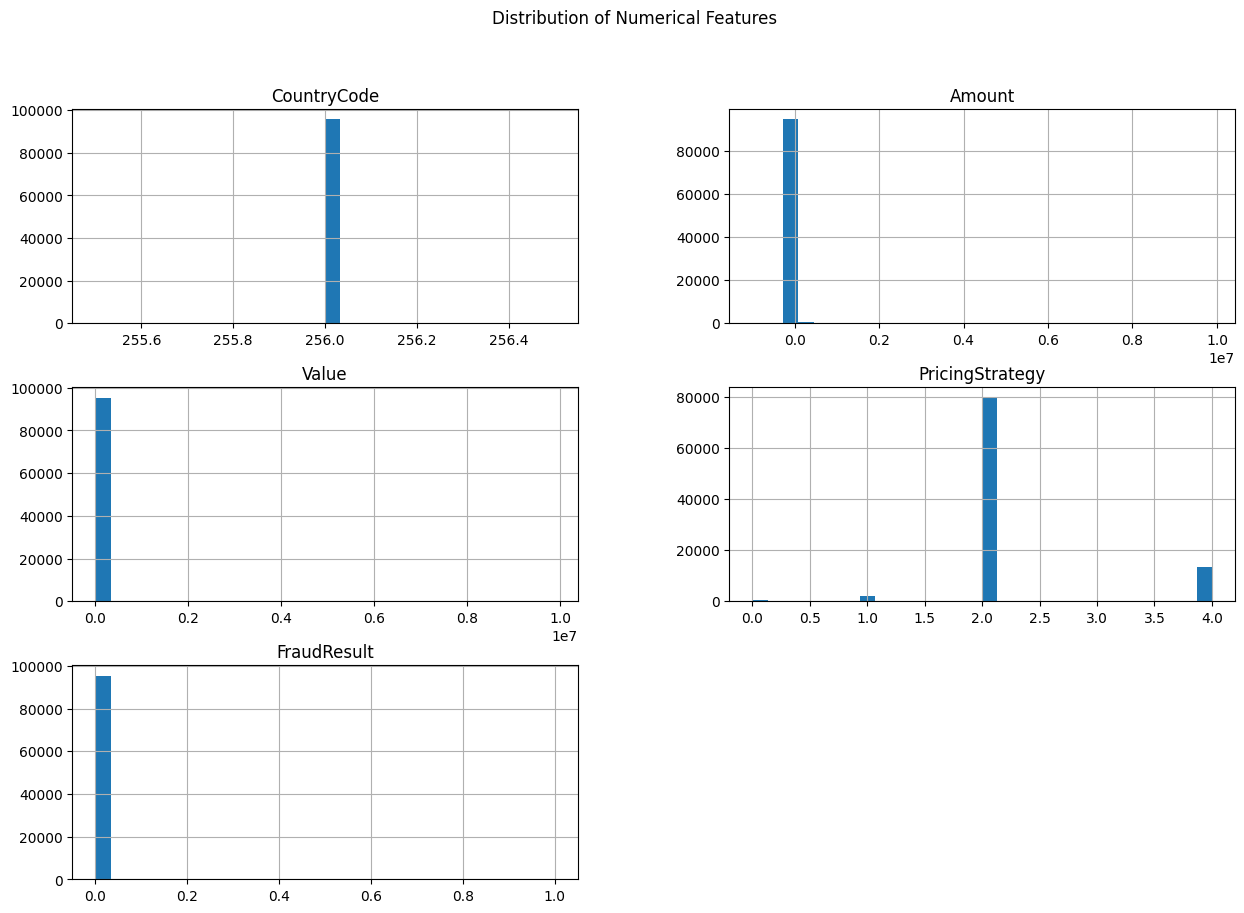

In [9]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [10]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

C:\Users\samiy\AppData\Local\Temp\ipykernel_34244\910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

In [12]:
for col in cat_cols:
    print(f"\n{col} Value Counts:")
    print(df[col].value_counts().head(10))


TransactionId Value Counts:
TransactionId
TransactionId_76871     1
TransactionId_73770     1
TransactionId_26203     1
TransactionId_380       1
TransactionId_28195     1
TransactionId_23223     1
TransactionId_118063    1
TransactionId_100640    1
TransactionId_51905     1
TransactionId_130161    1
Name: count, dtype: int64

BatchId Value Counts:
BatchId
BatchId_67019     28
BatchId_51870     16
BatchId_113893    14
BatchId_127204    12
BatchId_116835    10
BatchId_88001      9
BatchId_49408      7
BatchId_110084     7
BatchId_86880      6
BatchId_4233       6
Name: count, dtype: int64

AccountId Value Counts:
AccountId
AccountId_4841    30893
AccountId_4249     4457
AccountId_4840     1738
AccountId_3206     1105
AccountId_318      1070
AccountId_10        965
AccountId_3595      465
AccountId_751       411
AccountId_2648      359
AccountId_2314      356
Name: count, dtype: int64

SubscriptionId Value Counts:
SubscriptionId
SubscriptionId_3829    32630
SubscriptionId_4429     4457


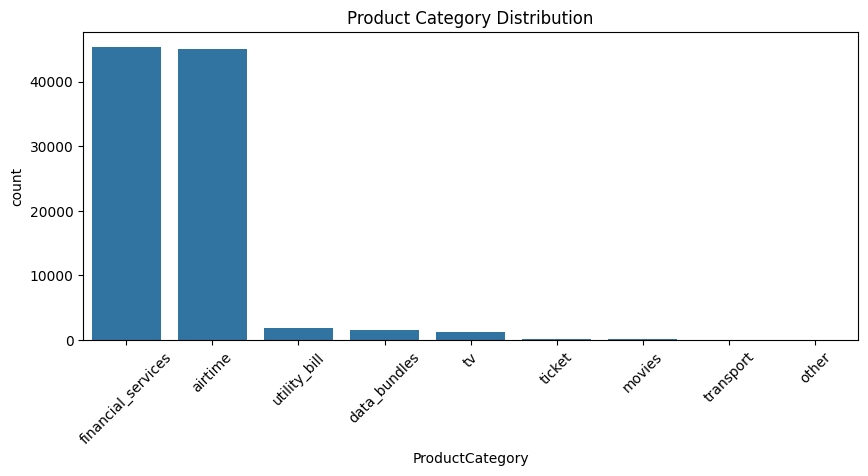

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='ProductCategory', order=df['ProductCategory'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Product Category Distribution")
plt.show()

From the product Catagory financial services hold the most customers transaction and other hold the least.

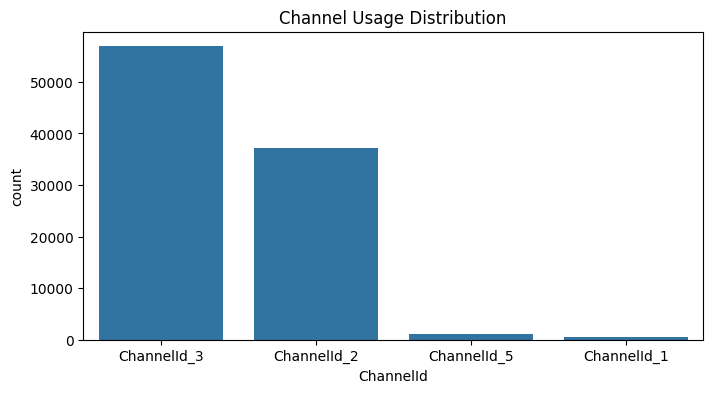

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='ChannelId', order=df['ChannelId'].value_counts().index)
plt.title("Channel Usage Distribution")
plt.show()

From the  Channels used Channelid_3 hold the most customers transaction an d customerid_1 holds the least.

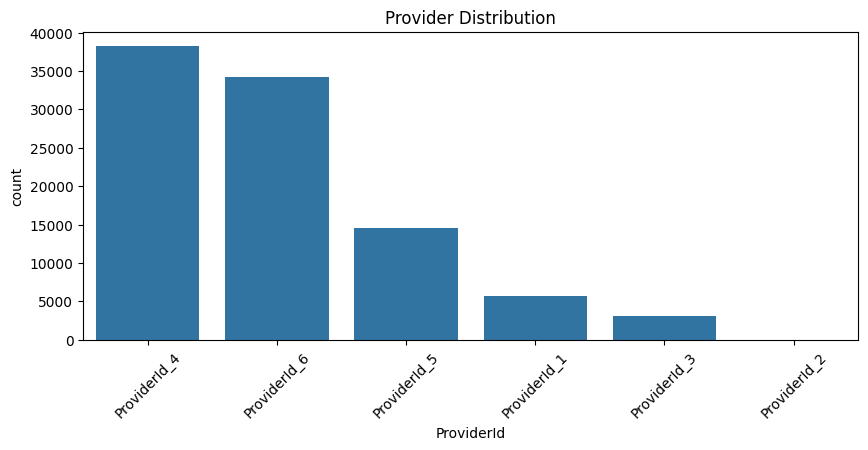

In [15]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='ProviderId', order=df['ProviderId'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Provider Distribution")
plt.show()

From the service Providers Providerid_4  hold the most customers transaction and Providerid_2 hold the least

📊 Correlation Analysis

In [16]:
corr_matrix = df[num_cols].corr()
corr_matrix

,CountryCode,Amount,Value,PricingStrategy,FraudResult
CountryCode,NaN,NaN,NaN,NaN,NaN
Amount,NaN,1.000000,0.989692,-0.061931,0.557370
Value,NaN,0.989692,1.000000,-0.017020,0.566739
PricingStrategy,NaN,-0.061931,-0.017020,1.000000,-0.033821
FraudResult,NaN,0.557370,0.566739,-0.033821,1.000000


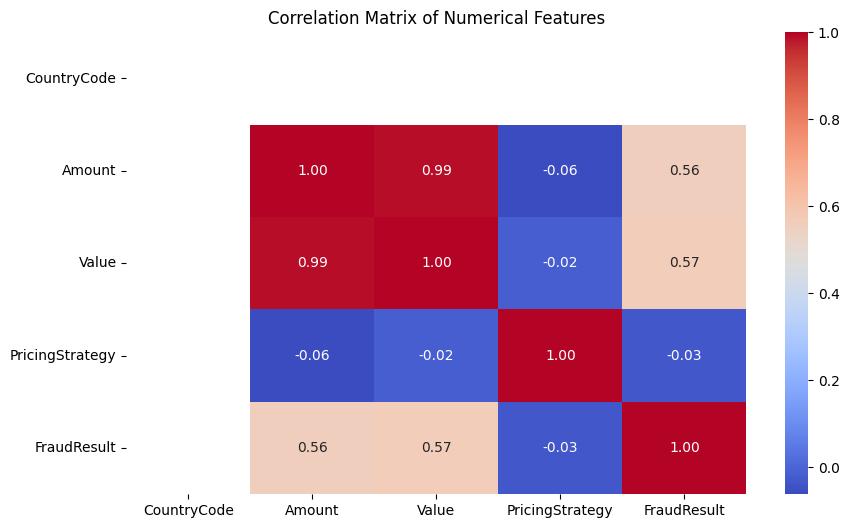

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Amount ↔ Value = 0.9897
Almost perfect positive correlation

FraudResult ↔ Amount = 0.557
FraudResult ↔ Value = 0.567
Moderate positive correlation

PricingStrategy ↔ others ≈ 0
Almost no linear relationship with other variables

The correlation analysis reveals several important patterns in the dataset. A near-perfect positive correlation (0.99) exists between Amount and Value, indicating that both variables carry almost identical information. As a result, one of these features may be redundant and should be carefully considered during feature selection to avoid multicollinearity.

FraudResult shows a moderate positive correlation with both Amount and Value, suggesting that higher-value transactions are more likely to be associated with fraud. This is an important behavioral signal for risk modeling.

PricingStrategy shows weak or negligible correlation with other numerical variables, indicating that it captures an independent aspect of transaction behavior.

CountryCode could not be meaningfully included in the correlation analysis, suggesting that it behaves as a categorical variable rather than a numerical feature.

Overall, the dataset exhibits a mix of strong and weak relationships, which will inform feature selection and model development in later stages.

 Outlier Detection Using Boxplots

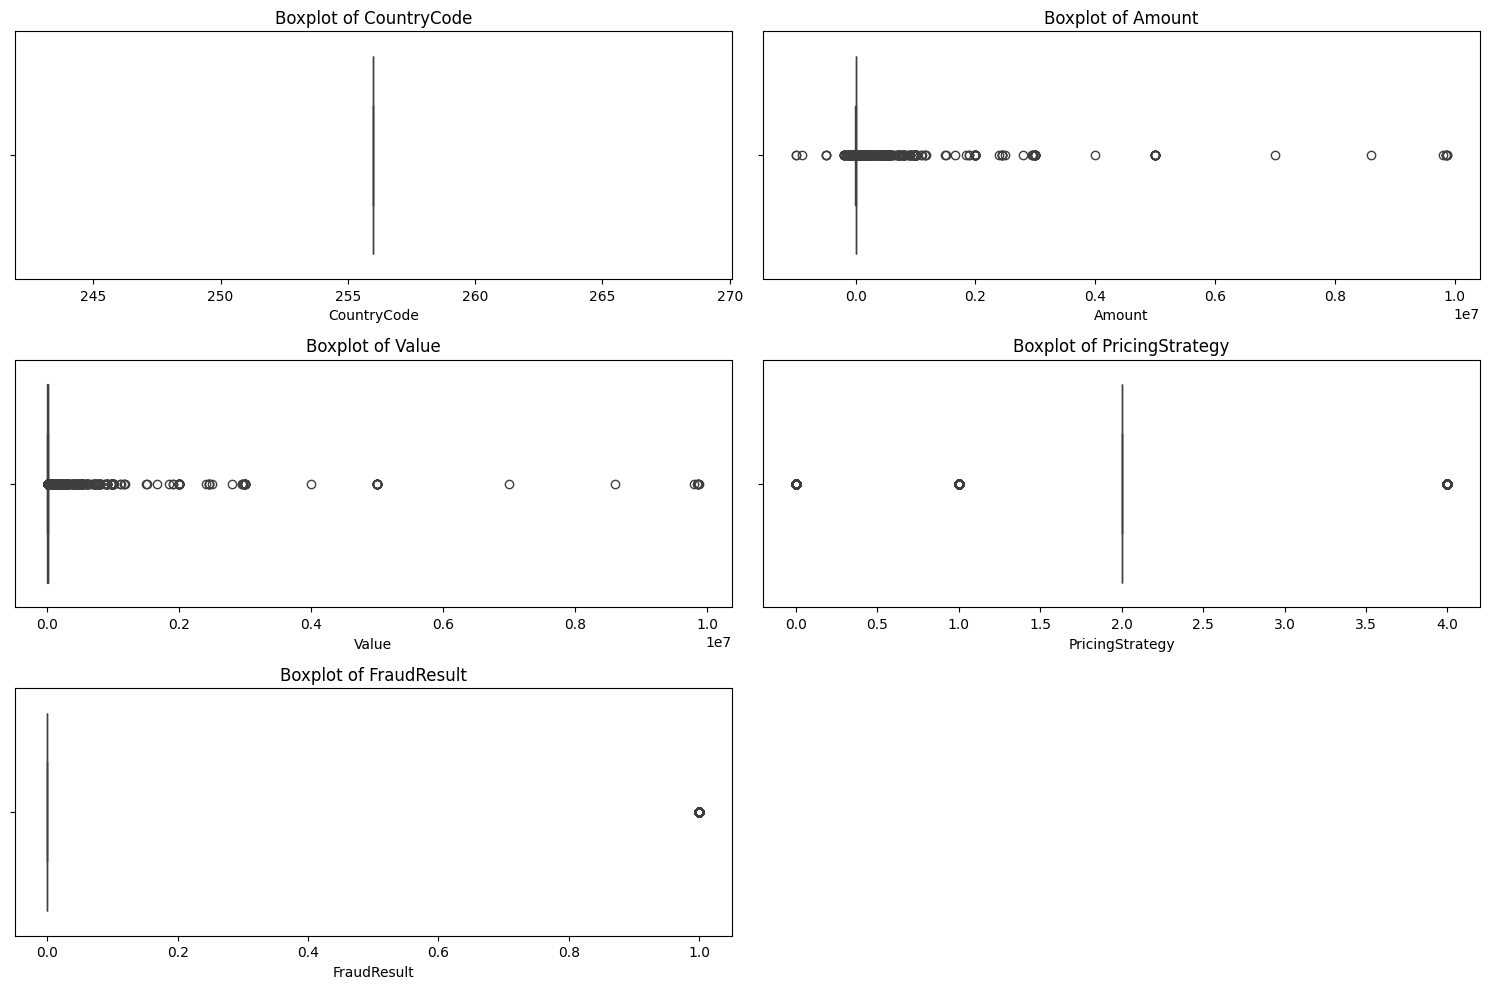

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

Boxplots were used to detect outliers in the numerical features of the dataset. Significant outliers were observed in transaction-related variables such as Amount and Value, indicating the presence of high-value transactions and potentially unusual financial behavior.

These outliers are expected in financial datasets and may represent important behavioral signals such as premium customers or fraudulent transactions. Therefore, they will not be removed outright but will instead be handled using appropriate transformation techniques such as scaling or log transformation.

Other numerical features showed limited or no significant outliers, suggesting stable distributions.